# Neural Network with PyTorch

A simple MNIST digit classifier implemented using PyTorch.

This is the library-based version of my neural network from scratch.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

print("Training images:", len(train_data))
print("Test images:", len(test_data))

100.0%
100.0%
100.0%
100.0%

Training images: 60000
Test images: 10000


In [3]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


In [4]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [5]:
for epoch in range(5):

    for images, labels in train_loader:

        predictions = model(images)

        loss = loss_fn(predictions, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}/5 | Loss: {loss.item():.4f}")

Epoch 1/5 | Loss: 0.1205
Epoch 2/5 | Loss: 0.1117
Epoch 3/5 | Loss: 0.2087
Epoch 4/5 | Loss: 0.0115
Epoch 5/5 | Loss: 0.0456


In [6]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        predictions = model(images)
        predicted_labels = predictions.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted_labels == labels).sum().item()

accuracy = correct / total

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 97.35%


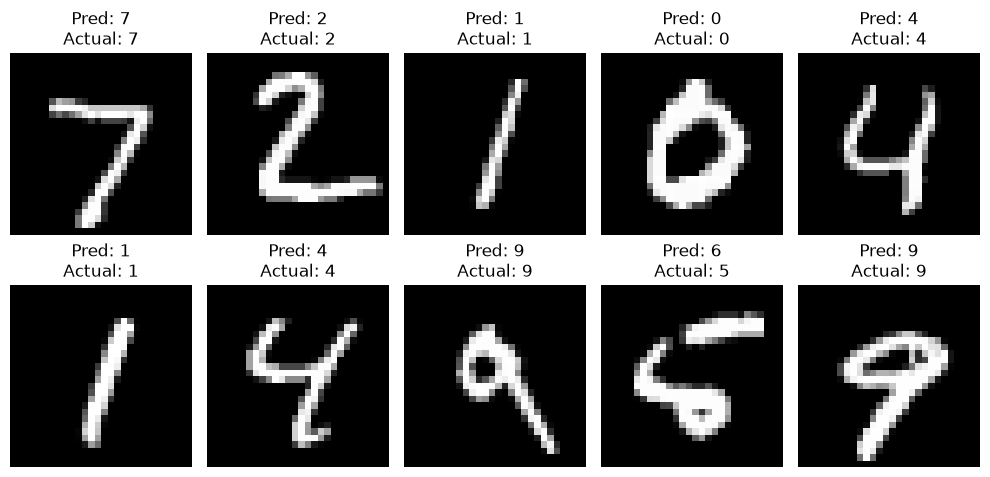

In [7]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    predictions = model(images).argmax(dim=1)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Pred: {predictions[i]}\nActual: {labels[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()